In [151]:
import numpy as np
import sympy as sp
import control as ct
import matplotlib.pyplot as plt
import scipy.signal
import scipy.linalg
import cvxpy as cp

In [152]:
x, v, theta, omega = sp.symbols('x  v theta omega') # States
m, M, L, g, delta, u = sp.symbols('m M L g delta u') # Physical Parameters

f = sp.Matrix([
    v,
    (-m**2*L**2*g*sp.sin(theta)*sp.cos(theta) + m*L**2*(m*L*omega**2*sp.sin(theta) - delta*v) + m*L**2*u)/(m*L**2*(M + m*(1 - sp.cos(theta)**2))),
    omega,
    ((m+M)*m*g*L*sp.sin(theta) - m*L*sp.cos(theta)*(m*L*omega**2*sp.sin(theta)-delta*v) - m*L*sp.cos(theta)*u) / (m*L**2*(M+m*(1 - sp.cos(theta)**2)))
])

x_vec = sp.Matrix([x, v, theta, omega])
u_vec = sp.Matrix([u])

A_sym = f.jacobian(x_vec)
B_sym = f.jacobian(u_vec)

params = {m : 1, M : 5, L : 2, g : -10, delta : 1}
A_params = A_sym.subs(params)
B_params = B_sym.subs(params)

eq1 = {v : 0, theta : 0, omega : 0}
eq2 = {v : 0, theta : sp.pi, omega : 0}

A_eq1 = A_params.subs(eq1)
B_eq1 = B_params.subs(eq1)

A_eq2 = A_params.subs(eq2)
B_eq2 = B_params.subs(eq2)

sp.init_printing
#display(A_eq1)
#display(B_eq1)
display(A_eq2)
display(B_eq2)


Matrix([
[0,     1, 0, 0],
[0,  -1/5, 2, 0],
[0,     0, 0, 1],
[0, -1/10, 6, 0]])

Matrix([
[   0],
[ 1/5],
[   0],
[1/10]])

In [153]:
A1 = np.array(A_eq1).astype(np.float64)
B1 = np.array(B_eq1).astype(np.float64)
A2 = np.array(A_eq2).astype(np.float64)
B2 = np.array(B_eq2).astype(np.float64)

print('Matrix rank is', np.linalg.matrix_rank(ct.ctrb(A1,B1)))
print('Matrix rank is', np.linalg.matrix_rank(ct.ctrb(A2,B2)))

Matrix rank is 4
Matrix rank is 4


In [154]:
A = A2
B = B2

dt = 0.1

sys = scipy.signal.StateSpace(A,B, np.eye(4), np.zeros((4,1)))
sysd = sys.to_discrete(dt)

Ad = sysd.A
Bd = sysd.B
Cd = sysd.C
Dd = sysd.D

Q = np.diag([0,1,1,1])
R = np.array([0.0001])

K, S, E = ct.dlqr(Ad, Bd, Q, R)

In [155]:
f_num = sp.lambdify((x, v, theta, omega, u), f.subs(params), 'numpy')

def nonlinear_dynamics(t, statevec, uval):
    xs, vs, ths, ws = statevec
    return f_num(xs, vs, ths, ws, uval).flatten()

xeq = np.array([0.0, 0.0, np.pi, 0.0])
x0 = np.array([ -1, 0, np.pi + 0.1, 0.0])

tfinal = 8.0
nsteps = int(tfinal / dt)

thist = [0.0]
xhist = [x0.copy()]
uhist = []

statenow = x0.copy()
for k in range(nsteps):
    err = statenow - xeq
    uval = float((-K @ err).item())
    uhist.append(uval)

    sol = scipy.integrate.solve_ivp(
        nonlinear_dynamics, [0, dt], statenow, args = (uval,),
        method = 'RK45', max_step = dt / 10
    )

    statenow = sol.y[:, -1]
    thist.append(thist[-1] + dt)
    xhist.append(statenow.copy())

t_hist = np.array(thist)
x_hist = np.array(xhist)
u_hist = np.array(uhist)

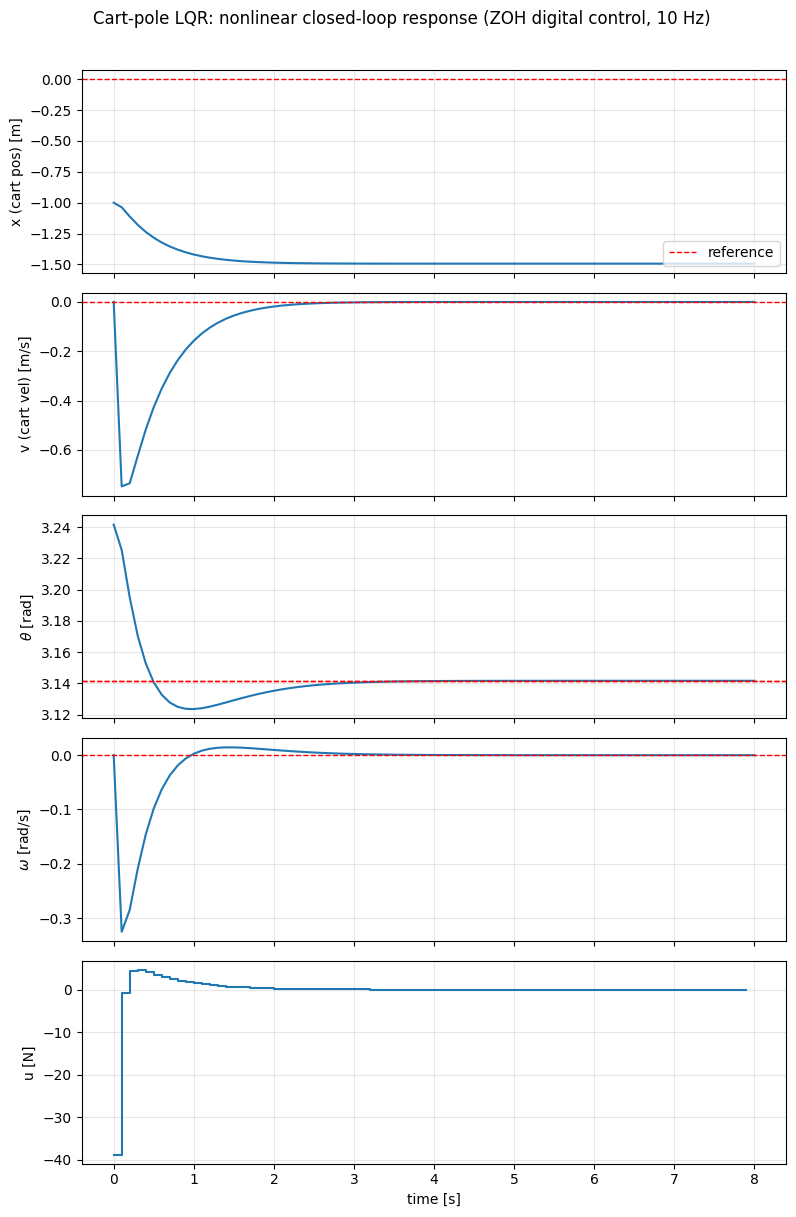

In [156]:
fig, axs = plt.subplots(5, 1, figsize=(8, 12), sharex=True)
labels = ['x (cart pos) [m]', 'v (cart vel) [m/s]', r'$\theta$ [rad]', r'$\omega$ [rad/s]']

for i in range(4):
    axs[i].plot(t_hist, x_hist[:, i])
    axs[i].axhline(xeq[i], color='r', ls='--', lw=1, label='reference')
    axs[i].set_ylabel(labels[i])
    axs[i].grid(alpha=0.3)
axs[2].axhline(np.pi, color='r', ls='--', lw=1)   # reference already correct, kept explicit for clarity

axs[4].step(t_hist[:-1], u_hist, where='post')
axs[4].set_ylabel('u [N]')
axs[4].set_xlabel('time [s]')
axs[4].grid(alpha=0.3)

axs[0].legend(loc='lower right')
plt.suptitle('Cart-pole LQR: nonlinear closed-loop response (ZOH digital control, 10 Hz)', y=1.01)
plt.tight_layout()
plt.show()
